# Partie 3 — MCTNet+



## 0. Imports & Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import math
# ── Hyperparamètres (calibrés anti-overfitting) ──────────────────
BATCH_SIZE   = 32
EPOCHS       = 200
LR           = 3e-4
WEIGHT_DECAY = 5e-4
DROPOUT      = 0.40
PROJ_DIM     = 64
GRU_HIDDEN   = 128
GRU_LAYERS   = 1
LABEL_SMOOTH = 0.10
MIXUP_ALPHA  = 0.00
NOISE_STD    = 0.02
TRAIN_N      = 240
VAL_N        = 60

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'Hyperparamètres anti-overfitting :')
print(f'  BATCH_SIZE={BATCH_SIZE} | DROPOUT={DROPOUT} | WEIGHT_DECAY={WEIGHT_DECAY}')
print(f'  PROJ_DIM={PROJ_DIM} | GRU_HIDDEN={GRU_HIDDEN} | GRU_LAYERS={GRU_LAYERS}')
print(f'  LABEL_SMOOTH={LABEL_SMOOTH} | MIXUP_ALPHA={MIXUP_ALPHA} | NOISE_STD={NOISE_STD}')

Device : cuda
Hyperparamètres anti-overfitting :
  BATCH_SIZE=32 | DROPOUT=0.4 | WEIGHT_DECAY=0.0005
  PROJ_DIM=64 | GRU_HIDDEN=128 | GRU_LAYERS=1
  LABEL_SMOOTH=0.1 | MIXUP_ALPHA=0.0 | NOISE_STD=0.02


## 1. Chargement des données

In [ ]:
dossier = '/content/drive/MyDrive/MCTNet_final'

pixels_ar  = np.load(dossier + '/pixels_arkansas.npy')
labels_ar  = np.load(dossier + '/labels_arkansas.npy', allow_pickle=True)
pixels_cal = np.load(dossier + '/pixels_california.npy')
labels_cal = np.load(dossier + '/labels_california.npy', allow_pickle=True)

def load_cov(path):
    if not os.path.exists(path): return None
    return np.load(path)

cov_clim_ar  = load_cov(dossier + '/cov_climate_arkansas.npy')
cov_soil_ar  = load_cov(dossier + '/cov_soil_arkansas.npy')
cov_topo_ar  = load_cov(dossier + '/cov_topo_arkansas.npy')
cov_clim_cal = load_cov(dossier + '/cov_climate_california.npy')
cov_soil_cal = load_cov(dossier + '/cov_soil_california.npy')
cov_topo_cal = load_cov(dossier + '/cov_topo_california.npy')

print(f'Arkansas   : {pixels_ar.shape} | California : {pixels_cal.shape}')

Arkansas   : (10000, 36, 10) | California : (10000, 36, 10)


## 2. Préparation des covariables

In [ ]:
def preparer_covariables(pixels, cov_clim=None, cov_soil=None, cov_topo=None):
    N, T, _ = pixels.shape
    # S2 normalisé [0,1]
    s2_norm = pixels.astype(np.float32) / 10000.0
    parts   = [s2_norm]

    if cov_clim is not None:
        if cov_clim.ndim == 2:
            cov_clim = cov_clim.reshape(N, T, -1)
        # Normalisation par bande temporelle séparément
        clim_flat = cov_clim.reshape(N * T, -1).astype(np.float32)
        clim_norm = StandardScaler().fit_transform(clim_flat)
        clim_norm = np.clip(clim_norm, -3, 3) / 3.0
        parts.append(clim_norm.reshape(N, T, -1))
        print(f'  + Climat  : {clim_norm.shape[1]} bandes')

    if cov_soil is not None:
        soil_norm = StandardScaler().fit_transform(cov_soil.astype(np.float32))
        soil_norm = np.clip(soil_norm, -3, 3) / 3.0
        parts.append(np.repeat(soil_norm[:, np.newaxis, :], T, axis=1))
        print(f'  + Sol     : {soil_norm.shape[1]} bandes')

    if cov_topo is not None:
        topo_norm = StandardScaler().fit_transform(cov_topo.astype(np.float32))
        topo_norm = np.clip(topo_norm, -3, 3) / 3.0
        parts.append(np.repeat(topo_norm[:, np.newaxis, :], T, axis=1))
        print(f'  + Topo    : {topo_norm.shape[1]} bandes')

    result = np.concatenate(parts, axis=2)
    print(f'  → Entrée finale : {result.shape}  '
          f'[min={result.min():.2f} max={result.max():.2f}]')
    return result

print('── Arkansas ──')
X_ar_s2   = preparer_covariables(pixels_ar)
X_ar_topo = preparer_covariables(pixels_ar, cov_topo=cov_topo_ar)
X_ar_soil = preparer_covariables(pixels_ar, cov_soil=cov_soil_ar)
X_ar_clim = preparer_covariables(pixels_ar, cov_clim=cov_clim_ar)
X_ar_all  = preparer_covariables(pixels_ar, cov_clim=cov_clim_ar,
                                  cov_soil=cov_soil_ar, cov_topo=cov_topo_ar)
print('── California ──')
X_cal_s2   = preparer_covariables(pixels_cal)
X_cal_topo = preparer_covariables(pixels_cal, cov_topo=cov_topo_cal)
X_cal_soil = preparer_covariables(pixels_cal, cov_soil=cov_soil_cal)
X_cal_clim = preparer_covariables(pixels_cal, cov_clim=cov_clim_cal)
X_cal_all  = preparer_covariables(pixels_cal, cov_clim=cov_clim_cal,
                                   cov_soil=cov_soil_cal, cov_topo=cov_topo_cal)

── Arkansas ──
  → Entrée finale : (10000, 36, 10)  [min=0.00 max=1.62]
  + Topo    : 2 bandes
  → Entrée finale : (10000, 36, 12)  [min=-1.00 max=1.62]
  + Sol     : 3 bandes
  → Entrée finale : (10000, 36, 13)  [min=-1.00 max=1.62]
  + Climat  : 3 bandes
  → Entrée finale : (10000, 36, 13)  [min=-0.62 max=1.62]
  + Climat  : 3 bandes
  + Sol     : 3 bandes
  + Topo    : 2 bandes
  → Entrée finale : (10000, 36, 18)  [min=-1.00 max=1.62]
── California ──
  → Entrée finale : (10000, 36, 10)  [min=0.00 max=1.16]
  + Topo    : 2 bandes
  → Entrée finale : (10000, 36, 12)  [min=-1.00 max=1.16]
  + Sol     : 3 bandes
  → Entrée finale : (10000, 36, 13)  [min=-1.00 max=1.16]
  + Climat  : 3 bandes
  → Entrée finale : (10000, 36, 13)  [min=-0.68 max=1.16]
  + Climat  : 3 bandes
  + Sol     : 3 bandes
  + Topo    : 2 bandes
  → Entrée finale : (10000, 36, 18)  [min=-1.00 max=1.16]


## 3. Architecture MCTNet+ (anti-overfitting)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CBAM — Channel Attention  (Wang et al. 2021)
# ═══════════════════════════════════════════════════════════════
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(),
            nn.Linear(mid, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):          # x : (B, C, T)
        avg_w = self.mlp(self.avg_pool(x).squeeze(-1))
        max_w = self.mlp(self.max_pool(x).squeeze(-1))
        return x * self.sigmoid(avg_w + max_w).unsqueeze(-1)


# ═══════════════════════════════════════════════════════════════
# CBAM — Temporal Attention  (Wang et al. 2021)
# ═══════════════════════════════════════════════════════════════
class TemporalAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv1d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):          # x : (B, C, T)
        avg_t = x.mean(dim=1, keepdim=True)
        max_t = x.max(dim=1,  keepdim=True)[0]
        return x * self.sigmoid(self.conv(torch.cat([avg_t, max_t], dim=1)))


# ═══════════════════════════════════════════════════════════════
# ResBlock1D + CBAM canal  (He et al. 2016 + Wang et al. 2021)
# ═══════════════════════════════════════════════════════════════
class ResBlock1D(nn.Module):
    def __init__(self, channels, kernel_size=3, dropout=0.5):
        super().__init__()
        pad = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad, bias=False),
            nn.BatchNorm1d(channels),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=pad, bias=False),
            nn.BatchNorm1d(channels),
        )
        self.cbam_ch = ChannelAttention(channels)
        self.relu    = nn.ReLU(inplace=True)

    def forward(self, x):          # x : (B, C, T)
        out = self.net(x)
        out = self.cbam_ch(out)    # attention canal
        return self.relu(out + x)  # skip connection


# ═══════════════════════════════════════════════════════════════
# BiGRU + attention temporelle CBAM  (Tufail et al. 2025)
# ═══════════════════════════════════════════════════════════════
class BiGRUTemporalBlock(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.5):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        out_size = hidden_size * 2
        self.bn           = nn.BatchNorm1d(out_size)
        self.temporal_att = TemporalAttention(kernel_size=5)
        self.dropout      = nn.Dropout(p=dropout)

    def forward(self, x, mask=None):   # x : (B, T, C)
        if mask is not None:
            lengths  = mask.sum(dim=1).long().clamp(min=1).cpu()
            packed   = nn.utils.rnn.pack_padded_sequence(
                x, lengths, batch_first=True, enforce_sorted=False)
            out, _   = self.gru(packed)
            out, _   = nn.utils.rnn.pad_packed_sequence(
                out, batch_first=True, total_length=x.size(1))
        else:
            out, _ = self.gru(x)

        out = out.transpose(1, 2)
        out = self.bn(out)
        out = self.temporal_att(out)
        out = self.dropout(out)
        return out


# ═══════════════════════════════════════════════════════════════
# MCTNet+  — architecture
# ═══════════════════════════════════════════════════════════════
class MCTNetPlus(nn.Module):

    def __init__(self, num_classes, n_bands=10, n_steps=36,
                 proj_dim=32, gru_hidden=64, gru_layers=1, dropout=0.5):
        super().__init__()

        # ── Projection d'entrée ──
        self.proj_in = nn.Sequential(
            nn.Linear(n_bands, proj_dim, bias=False),
            nn.LayerNorm(proj_dim)
        )

        # ── Stage 1 : résolution temporelle complète (T) ──
        self.stage1 = nn.Sequential(
            ResBlock1D(proj_dim, kernel_size=3, dropout=dropout),
            ResBlock1D(proj_dim, kernel_size=5, dropout=dropout),
        )
        self.pool1  = nn.MaxPool1d(2)
        self.proj1  = nn.Sequential(
            nn.Conv1d(proj_dim, proj_dim*2, 1, bias=False),
            nn.BatchNorm1d(proj_dim*2)
        )

        # ── Stage 2 : résolution T//2 ──
        self.stage2 = nn.Sequential(
            ResBlock1D(proj_dim*2, kernel_size=3, dropout=dropout),
            ResBlock1D(proj_dim*2, kernel_size=5, dropout=dropout),
        )
        self.pool2  = nn.MaxPool1d(2)

        # ── BiGRU + attention temporelle ──
        self.bigru = BiGRUTemporalBlock(
            input_size=proj_dim*2,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            dropout=dropout
        )
        gru_out = gru_hidden * 2

        # ── Tête de classification ──
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier  = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(gru_out, num_classes)
        )

    def forward(self, x, mask=None):
        if x.dim() == 3 and x.shape[1] < x.shape[2]:
            x = x.transpose(1, 2)

        x = self.proj_in(x)
        x = x.transpose(1, 2)

        x = self.stage1(x)
        x = self.pool1(x)
        x = self.proj1(x)

        x = self.stage2(x)
        x = self.pool2(x)


        if mask is not None:
            mask_sub = F.avg_pool1d(
                mask.unsqueeze(1).float(), kernel_size=4, stride=4, ceil_mode=True
            ).squeeze(1)
            mask_sub = (mask_sub > 0).float()
        else:
            mask_sub = None

        x = x.transpose(1, 2)
        x = self.bigru(x, mask_sub)
        x = self.global_pool(x).squeeze(-1)
        return self.classifier(x)


# ── Vérification ────────────────────────────────────────────────
configs_nb = {'S2(10)':10, 'S2+Topo(12)':12, 'S2+Soil(13)':13, 'S2+All(18)':18}
print(f'  {"Config":<16} {"Params MCTNet+":>16}')
print('  ' + '-'*34)
for nom, nb in configs_nb.items():
    m = MCTNetPlus(5, n_bands=nb, proj_dim=PROJ_DIM, gru_hidden=GRU_HIDDEN)
    p = sum(x.numel() for x in m.parameters())
    print(f'  {nom:<16} {p:>16,}')

# Test forward
m_t = MCTNetPlus(5, n_bands=10, proj_dim=PROJ_DIM, gru_hidden=GRU_HIDDEN)
o_t = m_t(torch.randn(4, 36, 10), torch.ones(4, 36))
print(f'\n  Forward OK → {o_t.shape}')

  Config             Params MCTNet+
  ----------------------------------
  S2(10)                    558,863
  S2+Topo(12)               558,991
  S2+Soil(13)               559,055
  S2+All(18)                559,375

  Forward OK → torch.Size([4, 5])


## 4. Dataset + Data Augmentation (MixUp + Bruit gaussien)

In [ ]:
class CropDataset(Dataset):
    def __init__(self, pixels, mask, labels_enc, noise_std=0.0):
        self.X         = torch.tensor(pixels,     dtype=torch.float32)
        self.mask      = torch.tensor(mask,       dtype=torch.float32)
        self.y         = torch.tensor(labels_enc, dtype=torch.long)
        self.noise_std = noise_std

    def __len__(self): return len(self.y)

    def __getitem__(self, i):
        x = self.X[i]
        if self.noise_std > 0:
            # Bruit gaussien sur les entrées → régularisation implicite
            x = x + torch.randn_like(x) * self.noise_std
        return x, self.mask[i], self.y[i]


def mixup_batch(x, mask, y, alpha=0.3):

    if alpha <= 0:
        return x, y, y, 1.0
    lam   = np.random.beta(alpha, alpha)
    B     = x.size(0)
    idx   = torch.randperm(B, device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return x_mix, y_a, y_b, lam


def preparer_splits(labels_enc, train_n=240, val_n=60, seed=42):
    np.random.seed(seed)
    idx_tr, idx_val, idx_te = [], [], []
    for c in np.unique(labels_enc):
        idx_c = np.where(labels_enc == c)[0]
        np.random.shuffle(idx_c)
        tr = min(train_n, len(idx_c))
        v  = min(val_n, len(idx_c) - tr)
        idx_tr.extend(idx_c[:tr])
        idx_val.extend(idx_c[tr:tr+v])
        idx_te.extend(idx_c[tr+v:])
    return np.array(idx_tr), np.array(idx_val), np.array(idx_te)


class LabelSmoothingCE(nn.Module):
    """CrossEntropy avec label smoothing — Müller et al. 2019."""
    def __init__(self, num_classes, smoothing=0.10):
        super().__init__()
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        log_prob   = F.log_softmax(logits, dim=-1)
        smooth_val = self.smoothing / (self.num_classes - 1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, smooth_val)
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()

print('Dataset + MixUp + LabelSmoothingCE définis.')

Dataset + MixUp + LabelSmoothingCE définis.


## 5. Boucle d'entraînement (anti-overfitting)

In [ ]:
def dropout_adaptatif(n_bands, base_dropout=0.40):

    if n_bands <= 10:    return base_dropout
    elif n_bands <= 13:  return base_dropout + 0.05
    else:                return base_dropout + 0.10

def entrainer_p3(pixels_norm, labels, zone_nom, classes, config_nom='',
                 proj_dim=PROJ_DIM, gru_hidden=GRU_HIDDEN, gru_layers=GRU_LAYERS,
                 dropout=DROPOUT, n_epochs=EPOCHS, batch_size=BATCH_SIZE,
                 lr=LR, weight_decay=WEIGHT_DECAY,
                 label_smooth=LABEL_SMOOTH,
                 mixup_alpha=MIXUP_ALPHA, noise_std=NOISE_STD):

    print(f"\n{'='*65}")
    print(f'  MCTNet+ — {zone_nom}  [{config_nom}]  entrée:{pixels_norm.shape}')
    print(f"{'='*65}")

    n_bands = pixels_norm.shape[2]
    n_steps = pixels_norm.shape[1]

    dropout = dropout_adaptatif(n_bands, base_dropout=dropout)
    print(f'  Dropout adaptatif : {dropout:.2f} pour {n_bands} bandes')

    classes_presentes = [c for c in classes if c in np.unique(labels)]
    le         = LabelEncoder().fit(classes_presentes)
    n_classes  = len(classes_presentes)
    labels_enc = le.transform(labels)

    mask = (~np.all(pixels_norm[:, :, :10] == 0, axis=2)).astype(np.float32)

    idx_tr, idx_val, idx_te = preparer_splits(labels_enc, TRAIN_N, VAL_N)
    print(f'  Train={len(idx_tr)} | Val={len(idx_val)} | Test={len(idx_te)}')

    tr_dl  = DataLoader(
        CropDataset(pixels_norm[idx_tr], mask[idx_tr], labels_enc[idx_tr],
                    noise_std=noise_std),
        batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
    val_dl = DataLoader(
        CropDataset(pixels_norm[idx_val], mask[idx_val], labels_enc[idx_val]),
        batch_size=128, pin_memory=True)
    te_dl  = DataLoader(
        CropDataset(pixels_norm[idx_te], mask[idx_te], labels_enc[idx_te]),
        batch_size=128, pin_memory=True)

    model = MCTNetPlus(
        num_classes=n_classes, n_bands=n_bands, n_steps=n_steps,
        proj_dim=proj_dim, gru_hidden=gru_hidden, gru_layers=gru_layers,
        dropout=dropout
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    print(f'  Paramètres : {n_params:,}')

    decay_params    = [p for n, p in model.named_parameters()
                       if 'bn' not in n and 'bias' not in n and 'norm' not in n]
    no_decay_params = [p for n, p in model.named_parameters()
                       if 'bn' in n or 'bias' in n or 'norm' in n]
    opt = optim.AdamW([
        {'params': decay_params,    'weight_decay': weight_decay},
        {'params': no_decay_params, 'weight_decay': 0.0}
    ], lr=lr)

    crit = LabelSmoothingCE(num_classes=n_classes, smoothing=label_smooth)

    def lr_lambda(epoch):
        if epoch < 10:
           return epoch / 10
        return 0.5 * (1 + math.cos(math.pi * (epoch - 10) / (n_epochs - 10)))

    scheduler = optim.lr_scheduler.LambdaLR(opt, lr_lambda)

    best_val_acc = 0.0
    best_state   = None
    history      = {'train_loss': [], 'val_loss': [], 'val_acc': [],
                    'train_acc': [], 'gap': []}

    try:
        for epoch in range(1, n_epochs + 1):
            model.train()
            run_loss, run_correct, run_total = 0.0, 0, 0
            for x, m, y in tr_dl:
                x, m, y = x.to(device), m.to(device), y.to(device)

                x_mix, y_a, y_b, lam = mixup_batch(x, m, y, alpha=mixup_alpha)

                opt.zero_grad()
                logits = model(x_mix, m)
                loss = lam * crit(logits, y_a) + (1 - lam) * crit(logits, y_b)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                opt.step()

                run_loss    += loss.item() * len(y)
                run_correct += (logits.argmax(1) == y).sum().item()
                run_total   += len(y)

            train_loss = run_loss    / run_total
            train_acc  = run_correct / run_total
            scheduler.step()

            model.eval()
            preds_v, trues_v, val_loss_sum = [], [], 0.0
            with torch.no_grad():
                for x, m, y in val_dl:
                    x, m, y = x.to(device), m.to(device), y.to(device)
                    out = model(x, m)
                    val_loss_sum += F.cross_entropy(out, y).item() * len(y)
                    preds_v.extend(out.argmax(1).cpu().numpy())
                    trues_v.extend(y.cpu().numpy())

            val_acc  = accuracy_score(trues_v, preds_v)
            val_loss = val_loss_sum / len(val_dl.dataset)
            gap      = val_loss - train_loss

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['train_acc'].append(train_acc)
            history['gap'].append(gap)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state   = {k: v.clone() for k, v in model.state_dict().items()}

            if epoch % 20 == 0:
                lr_now = scheduler.get_last_lr()[0]
                print(f'  Ep {epoch:>3} | TrainL={train_loss:.3f} ValL={val_loss:.3f} '
                      f'Gap={gap:+.3f} | BestVal={best_val_acc:.4f} | lr={lr_now:.1e}')

    except KeyboardInterrupt:
        print('\n⚠️  Interrompu.')

    model.load_state_dict(best_state)
    model.eval()
    preds_te, trues_te = [], []
    with torch.no_grad():
        for x, m, y in te_dl:
            x, m = x.to(device), m.to(device)
            preds_te.extend(model(x, m).argmax(1).cpu().numpy())
            trues_te.extend(y.numpy())

    oa    = accuracy_score(trues_te, preds_te)
    kappa = cohen_kappa_score(trues_te, preds_te)
    f1    = f1_score(trues_te, preds_te, average='macro', zero_division=0)

    print(f'\n  TEST → OA={oa:.4f} | Kappa={kappa:.4f} | F1={f1:.4f}')
    print(f'  Gap final (ValLoss-TrainLoss) : {history["gap"][-1]:+.3f}')

    fname = (f'mctnetplus_{zone_nom.lower()}_'
             f'{config_nom.lower().replace(" ","_").replace("+","")}.pth')
    torch.save({'model_state_dict': best_state, 'classes': classes_presentes,
                'oa': oa, 'kappa': kappa, 'f1': f1, 'config': config_nom,
                'n_bands': n_bands,
                'hp': dict(proj_dim=proj_dim, gru_hidden=gru_hidden,
                           gru_layers=gru_layers, dropout=dropout)},
               dossier + '/' + fname)
    print(f'  Sauvegardé → {fname}')

    return oa, kappa, f1, best_state, le, trues_te, preds_te, history

print('Fonction entrainer_p3 définie.')

Fonction entrainer_p3 définie.


## 6. Entraînement toutes configurations

In [ ]:


# Arkansas
classes_ar = np.unique(labels_ar)
print(f'Arkansas   : {len(classes_ar)} classes → {classes_ar}')

# California
classes_cal = np.unique(labels_cal)
print(f'California : {len(classes_cal)} classes → {classes_cal}')

print(f'\n✓ Variables classes_ar et classes_cal définies')

resultats_p3   = {}
histories_p3   = {}
predictions_p3 = {}

cfg_nom = 'S2'
X_ar, X_cal = X_ar_s2, X_cal_s2

print(f"\n{'#'*65}\n# CONFIG : {cfg_nom}\n{'#'*65}")

oa_ar, k_ar, f1_ar, _, le_ar, tr_ar, pr_ar, hist_ar = entrainer_p3(
    X_ar, labels_ar, 'Arkansas', classes_ar, config_nom=cfg_nom,
    weight_decay=2e-4,
    label_smooth=0.07)

oa_cal, k_cal, f1_cal, _, le_cal, tr_cal, pr_cal, hist_cal = entrainer_p3(
    X_cal, labels_cal, 'California', classes_cal, config_nom=cfg_nom,
    weight_decay=5e-4,
    label_smooth=0.10)

resultats_p3[cfg_nom] = {
    'AR':  {'OA': oa_ar,  'Kappa': k_ar,  'F1': f1_ar},
    'CAL': {'OA': oa_cal, 'Kappa': k_cal, 'F1': f1_cal},
}
histories_p3[cfg_nom] = {'AR': hist_ar, 'CAL': hist_cal}
predictions_p3[cfg_nom] = {
    'AR':  {'trues': tr_ar,  'preds': pr_ar,  'le': le_ar},
    'CAL': {'trues': tr_cal, 'preds': pr_cal, 'le': le_cal},
}

Arkansas   : 5 classes → ['Corn' 'Cotton' 'Others' 'Rice' 'Soybeans']
California : 6 classes → ['Alfalfa' 'Almonds' 'Grapes' 'Others' 'Pistachios' 'Rice']

✓ Variables classes_ar et classes_cal définies

#################################################################
# CONFIG : S2
#################################################################

  MCTNet+ — Arkansas  [S2]  entrée:(10000, 36, 10)
  Dropout adaptatif : 0.40 pour 10 bandes
  Train=1200 | Val=300 | Test=8500
  Paramètres : 558,863
  Ep  20 | TrainL=0.607 ValL=0.367 Gap=-0.240 | BestVal=0.8967 | lr=3.0e-04
  Ep  40 | TrainL=0.503 ValL=0.350 Gap=-0.153 | BestVal=0.9200 | lr=2.8e-04
  Ep  60 | TrainL=0.450 ValL=0.299 Gap=-0.151 | BestVal=0.9200 | lr=2.5e-04
  Ep  80 | TrainL=0.432 ValL=0.301 Gap=-0.131 | BestVal=0.9267 | lr=2.1e-04
  Ep 100 | TrainL=0.411 ValL=0.362 Gap=-0.049 | BestVal=0.9267 | lr=1.6e-04
  Ep 120 | TrainL=0.403 ValL=0.295 Gap=-0.108 | BestVal=0.9267 | lr=1.1e-04
  Ep 140 | TrainL=0.394 ValL=0.322 Gap=-0.

**Visualisation**

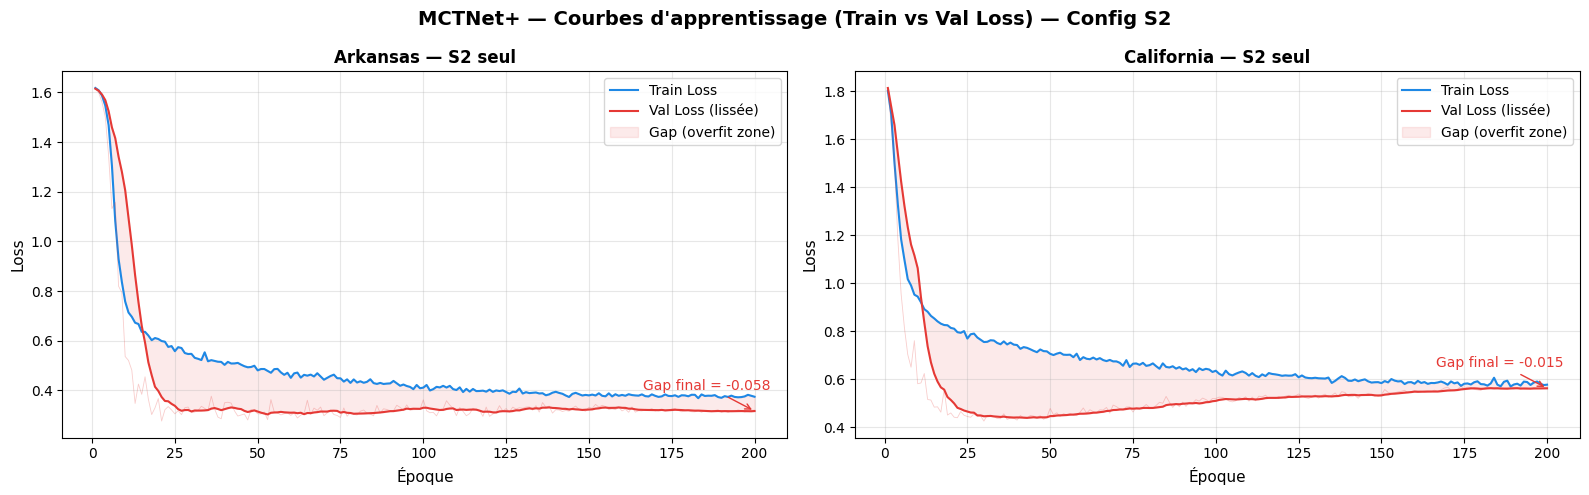

✅ Courbe S2 seul sauvegardée


In [ ]:
import pandas as pd

# ════════════════════════════════════════════════════════════════
# Courbe d'apprentissage — S2 seul (Arkansas + California)
# ════════════════════════════════════════════════════════════════
cfg = 'S2'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'MCTNet+ — Courbes d\'apprentissage (Train vs Val Loss) — Config {cfg}',
             fontsize=14, fontweight='bold')

for ax, zone, titre in zip(axes, ['AR', 'CAL'], ['Arkansas', 'California']):
    h  = histories_p3[cfg][zone]
    ep = range(1, len(h['train_loss']) + 1)


    val_smooth = pd.Series(h['val_loss']).rolling(10, min_periods=1).mean().values

    ax.plot(ep, h['train_loss'], color='#1E88E5', lw=1.5, label='Train Loss')
    ax.plot(ep, h['val_loss'],   color='#E53935', lw=0.6, alpha=0.25)          # brut en transparence
    ax.plot(ep, val_smooth,      color='#E53935', lw=1.5, label='Val Loss (lissée)')
    ax.fill_between(ep, h['train_loss'], val_smooth,
                    alpha=0.10, color='#E53935', label='Gap (overfit zone)')


    gap_final = val_smooth[-1] - h['train_loss'][-1]
    ax.annotate(f'Gap final = {gap_final:+.3f}',
                xy=(len(ep), val_smooth[-1]),
                xytext=(-80, 15), textcoords='offset points',
                fontsize=10, color='#E53935',
                arrowprops=dict(arrowstyle='->', color='#E53935'))

    ax.set_title(f'{titre} — S2 seul', fontsize=12, fontweight='bold')
    ax.set_xlabel('Époque', fontsize=11)
    ax.set_ylabel('Loss',   fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(dossier + '/p3_courbe_s2_seul.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'✅ Courbe S2 seul sauvegardée')

**Le rest de config**

In [ ]:
configs_reste = {
    'S2+Topo': (X_ar_topo, X_cal_topo),
    'S2+Soil': (X_ar_soil, X_cal_soil),
    'S2+Clim': (X_ar_clim, X_cal_clim),
    'S2+All':  (X_ar_all,  X_cal_all),
}

for cfg_nom, (X_ar, X_cal) in configs_reste.items():
    print(f"\n{'#'*65}\n# CONFIG : {cfg_nom}\n{'#'*65}")

    oa_ar, k_ar, f1_ar, _, le_ar, tr_ar, pr_ar, hist_ar = entrainer_p3(
        X_ar, labels_ar, 'Arkansas', classes_ar, config_nom=cfg_nom)


    if cfg_nom == 'S2+All':
        oa_cal, k_cal, f1_cal, _, le_cal, tr_cal, pr_cal, hist_cal = entrainer_p3(
            X_cal, labels_cal, 'California', classes_cal, config_nom=cfg_nom,
            mixup_alpha=0.10,
            noise_std=0.02,
            weight_decay=1e-3,
            lr=1e-4)
    else:
        oa_cal, k_cal, f1_cal, _, le_cal, tr_cal, pr_cal, hist_cal = entrainer_p3(
            X_cal, labels_cal, 'California', classes_cal, config_nom=cfg_nom)

    resultats_p3[cfg_nom] = {
        'AR':  {'OA': oa_ar,  'Kappa': k_ar,  'F1': f1_ar},
        'CAL': {'OA': oa_cal, 'Kappa': k_cal, 'F1': f1_cal},
    }
    histories_p3[cfg_nom] = {'AR': hist_ar, 'CAL': hist_cal}
    predictions_p3[cfg_nom] = {
        'AR':  {'trues': tr_ar,  'preds': pr_ar,  'le': le_ar},
        'CAL': {'trues': tr_cal, 'preds': pr_cal, 'le': le_cal},
    }


#################################################################
# CONFIG : S2+Topo
#################################################################

  MCTNet+ — Arkansas  [S2+Topo]  entrée:(10000, 36, 12)
  Dropout adaptatif : 0.45 pour 12 bandes
  Train=1200 | Val=300 | Test=8500
  Paramètres : 558,991
  Ep  20 | TrainL=0.725 ValL=0.356 Gap=-0.369 | BestVal=0.8767 | lr=3.0e-04
  Ep  40 | TrainL=0.624 ValL=0.307 Gap=-0.317 | BestVal=0.9067 | lr=2.8e-04
  Ep  60 | TrainL=0.575 ValL=0.341 Gap=-0.234 | BestVal=0.9067 | lr=2.5e-04
  Ep  80 | TrainL=0.536 ValL=0.366 Gap=-0.170 | BestVal=0.9200 | lr=2.1e-04
  Ep 100 | TrainL=0.513 ValL=0.378 Gap=-0.135 | BestVal=0.9200 | lr=1.6e-04
  Ep 120 | TrainL=0.501 ValL=0.373 Gap=-0.128 | BestVal=0.9233 | lr=1.1e-04
  Ep 140 | TrainL=0.492 ValL=0.378 Gap=-0.114 | BestVal=0.9233 | lr=6.8e-05
  Ep 160 | TrainL=0.486 ValL=0.392 Gap=-0.095 | BestVal=0.9233 | lr=3.2e-05
  Ep 180 | TrainL=0.483 ValL=0.378 Gap=-0.105 | BestVal=0.9233 | lr=8.1e-06
  Ep 20

## 7. Tableau comparatif MCTNet vs MCTNet+

In [ ]:
 # ── Remplacer avec vos vrais résultats de la Partie 2 ──
resultats_p2 = {
    'S2': {
        'AR':  {'OA': 0.8722, 'Kappa': 0.8235, 'F1': 0.8526},
        'CAL': {'OA': 0.8191, 'Kappa': 0.7676, 'F1': 0.7422}
    },
    'S2+Topo': {
        'AR':  {'OA': 0.8580, 'Kappa': 0.8044, 'F1': 0.8428},
        'CAL': {'OA': 0.8257, 'Kappa': 0.7739, 'F1': 0.7540}
    },
    'S2+Soil': {
        'AR':  {'OA': 0.8367, 'Kappa': 0.7754, 'F1': 0.8176},
        'CAL': {'OA': 0.8266, 'Kappa': 0.7765, 'F1': 0.7650}
    },
    'S2+Clim': {
        'AR':  {'OA': 0.8541, 'Kappa': 0.7991, 'F1': 0.8422},
        'CAL': {'OA': 0.8212, 'Kappa': 0.7701, 'F1': 0.7528}
    },
    'S2+All': {
        'AR':  {'OA': 0.7916, 'Kappa': 0.7222, 'F1': 0.7993},
        'CAL': {'OA': 0.8593, 'Kappa': 0.8155, 'F1': 0.7866}
    },
}
# ══════════════════════════════════════════════════════════════════
# Définition des configurations testées
# ══════════════════════════════════════════════════════════════════


configs = ['S2', 'S2+Topo', 'S2+Soil', 'S2+Clim', 'S2+All']

print('Configurations définies:')
for i, cfg in enumerate(configs, 1):
    print(f'  {i}. {cfg}')
print(f'\n✓ Variable configs définie ({len(configs)} configurations)')
print('\n' + '='*78)
print('  TABLEAU — MCTNet (P2) vs MCTNet+ (P3)')
print('='*78)
print(f'  {"Config":<10} {"Zone":>4}  {"Modèle":<12} {"OA":>7} {"Kappa":>8} {"F1":>8}  {"ΔOA":>8}')
print('  ' + '-'*76)
refs = {'AR':{'OA':0.968,'Kappa':0.951,'F1':0.933}, 'CAL':{'OA':0.852,'Kappa':0.806,'F1':0.829}}
for zone, r in refs.items():
    print(f'  {"Papier réf":<10} {zone:>4}  {"MCTNet":<12} {r["OA"]:>7.3f} {r["Kappa"]:>8.3f} {r["F1"]:>8.3f}')
print('  ' + '-'*76)
for cfg in configs:
    for zone in ['AR', 'CAL']:
        p2 = resultats_p2[cfg][zone]
        p3 = resultats_p3[cfg][zone]
        d  = p3['OA'] - p2['OA']
        print(f'  {cfg:<10} {zone:>4}  {"MCTNet":<12} {p2["OA"]:>7.3f} {p2["Kappa"]:>8.3f} {p2["F1"]:>8.3f}')
        print(f'  {"":<10} {zone:>4}  {"MCTNet+":<12} {p3["OA"]:>7.3f} {p3["Kappa"]:>8.3f} {p3["F1"]:>8.3f}  {d*100:>+7.2f}%')
    print('  ' + '-'*76)
print('='*78)

Configurations définies:
  1. S2
  2. S2+Topo
  3. S2+Soil
  4. S2+Clim
  5. S2+All

✓ Variable configs définie (5 configurations)

  TABLEAU — MCTNet (P2) vs MCTNet+ (P3)
  Config     Zone  Modèle            OA    Kappa       F1       ΔOA
  ----------------------------------------------------------------------------
  Papier réf   AR  MCTNet         0.968    0.951    0.933
  Papier réf  CAL  MCTNet         0.852    0.806    0.829
  ----------------------------------------------------------------------------
  S2           AR  MCTNet         0.872    0.824    0.853
               AR  MCTNet+        0.878    0.830    0.853    +0.56%
  S2          CAL  MCTNet         0.819    0.768    0.742
              CAL  MCTNet+        0.849    0.803    0.783    +3.00%
  ----------------------------------------------------------------------------
  S2+Topo      AR  MCTNet         0.858    0.804    0.843
               AR  MCTNet+        0.884    0.836    0.859    +2.58%
  S2+Topo     CAL  MCTNet    

## 8. Visualisations

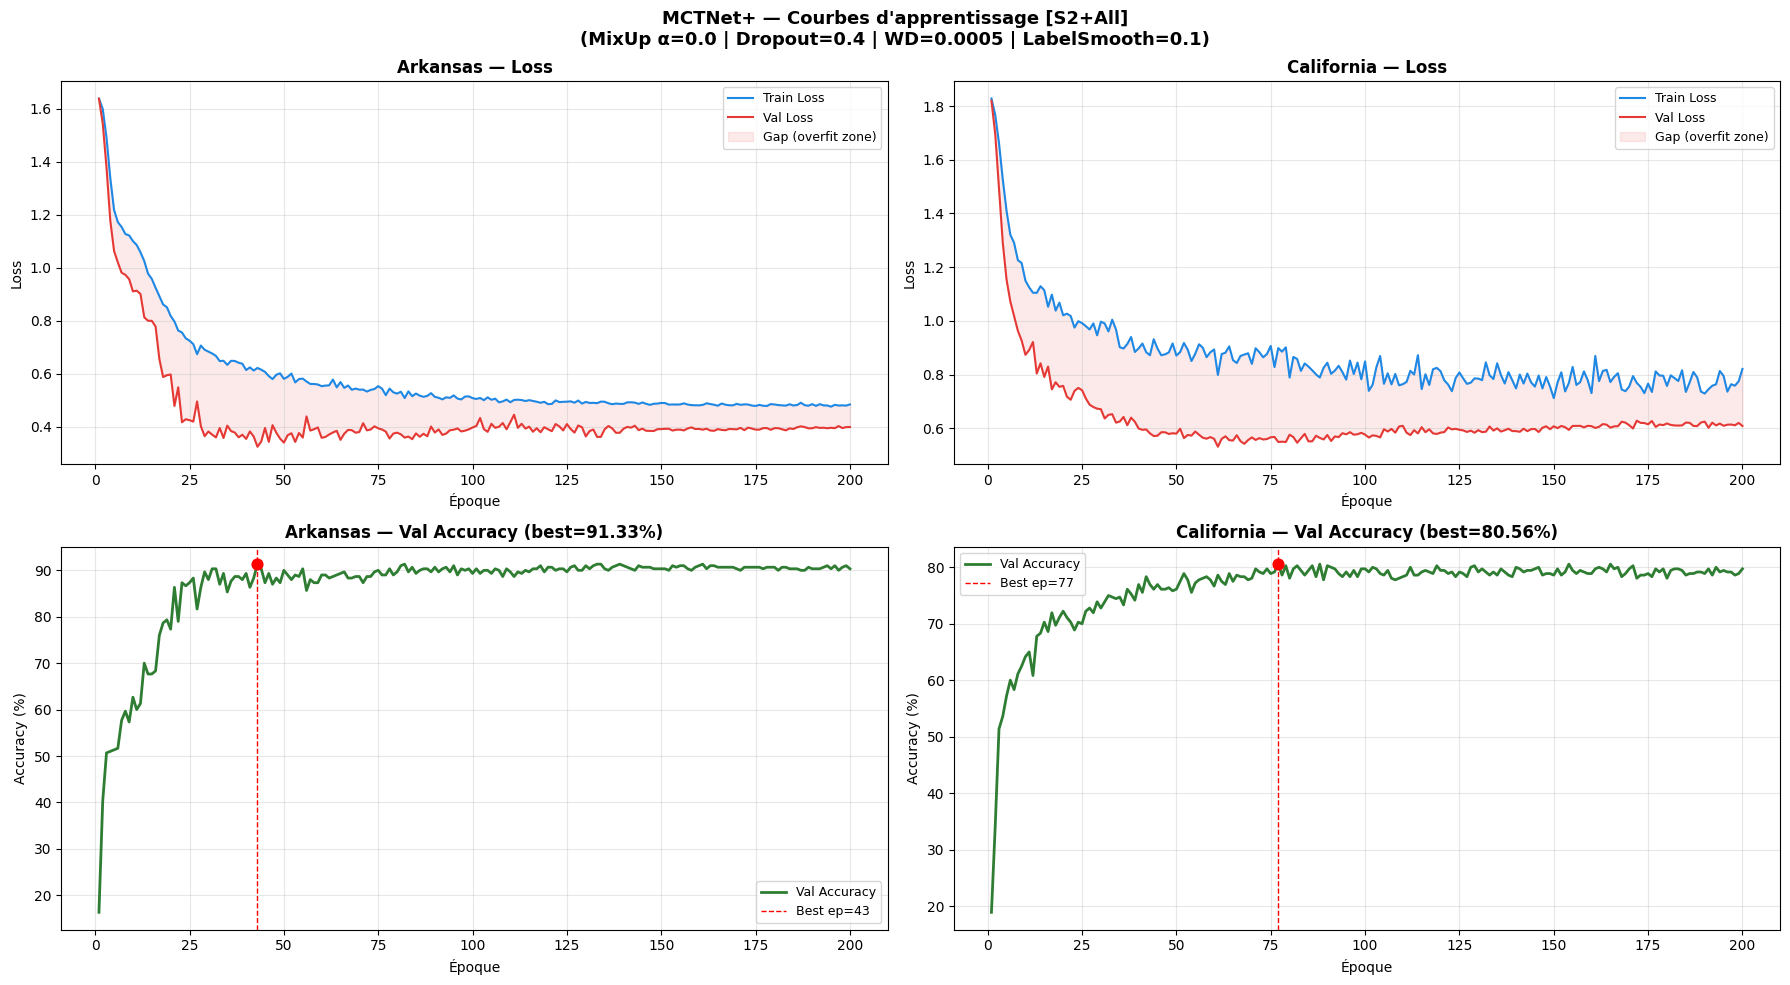

✅ Courbes sauvegardées


In [ ]:
# ════════════════════════════════════════════════════════════════
# 8.1 Courbes d'apprentissage (Train Loss / Val Loss / Gap)
# ════════════════════════════════════════════════════════════════
cfg_best = 'S2+All'

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle(f'MCTNet+ — Courbes d\'apprentissage [{cfg_best}]\n'
             f'(MixUp α={MIXUP_ALPHA} | Dropout={DROPOUT} | WD={WEIGHT_DECAY} | '
             f'LabelSmooth={LABEL_SMOOTH})',
             fontsize=13, fontweight='bold')

for col, (zone, titre) in enumerate([('AR','Arkansas'), ('CAL','California')]):
    h  = histories_p3[cfg_best][zone]
    ep = range(1, len(h['train_loss'])+1)

    # ── Ligne 1 : Loss curves ──
    ax = axes[0][col]
    ax.plot(ep, h['train_loss'], color='#1E88E5', lw=1.5, label='Train Loss')
    ax.plot(ep, h['val_loss'],   color='#E53935', lw=1.5, label='Val Loss')
    ax.fill_between(ep, h['train_loss'], h['val_loss'],
                    alpha=0.10, color='#E53935', label='Gap (overfit zone)')
    ax.set_title(f'{titre} — Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Époque'); ax.set_ylabel('Loss')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ── Ligne 2 : Val Accuracy ──
    ax2 = axes[1][col]
    ax2.plot(ep, [v*100 for v in h['val_acc']], color='#2E7D32', lw=2, label='Val Accuracy')
    best_ep = np.argmax(h['val_acc']) + 1
    best_acc = max(h['val_acc']) * 100
    ax2.axvline(best_ep, color='red', linestyle='--', lw=1, label=f'Best ep={best_ep}')
    ax2.scatter([best_ep], [best_acc], color='red', zorder=5, s=60)
    ax2.set_title(f'{titre} — Val Accuracy (best={best_acc:.2f}%)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Époque'); ax2.set_ylabel('Accuracy (%)')
    ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(dossier+'/p3_courbes_apprentissage.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅ Courbes sauvegardées')

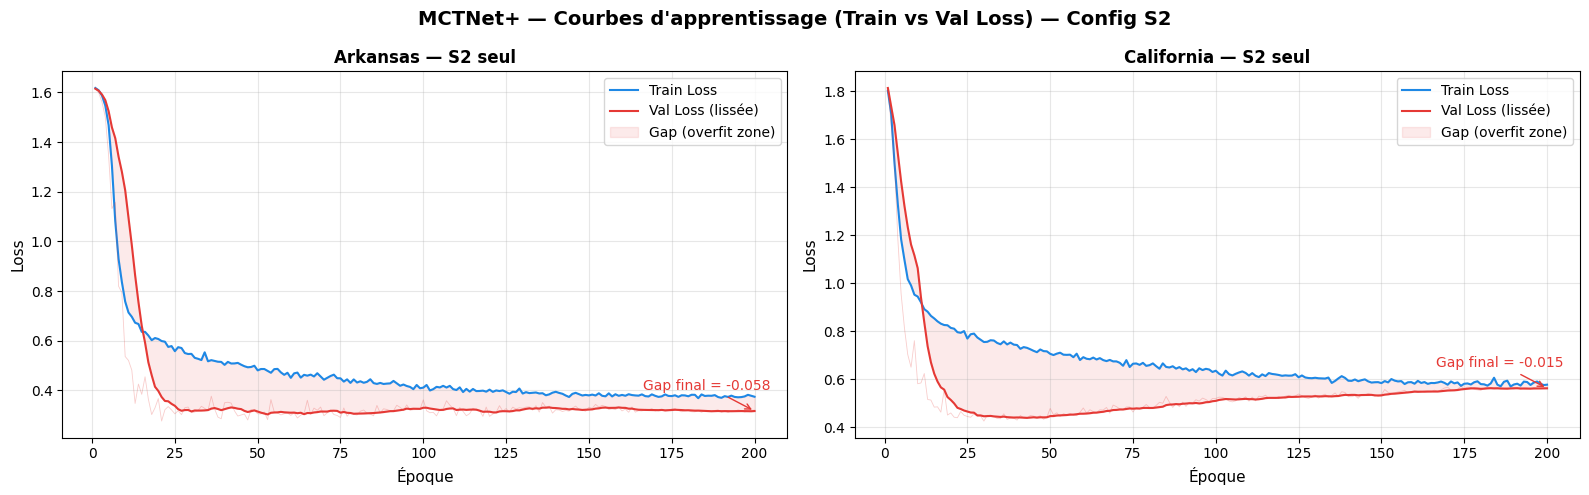

✅ Courbe S2 seul sauvegardée


In [ ]:
import pandas as pd

# ════════════════════════════════════════════════════════════════
# Courbe d'apprentissage — S2 seul (Arkansas + California)
# ════════════════════════════════════════════════════════════════
cfg = 'S2'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'MCTNet+ — Courbes d\'apprentissage (Train vs Val Loss) — Config {cfg}',
             fontsize=14, fontweight='bold')

for ax, zone, titre in zip(axes, ['AR', 'CAL'], ['Arkansas', 'California']):
    h  = histories_p3[cfg][zone]
    ep = range(1, len(h['train_loss']) + 1)

    # Lissage Val Loss (fenêtre 10 époques)
    val_smooth = pd.Series(h['val_loss']).rolling(10, min_periods=1).mean().values

    ax.plot(ep, h['train_loss'], color='#1E88E5', lw=1.5, label='Train Loss')
    ax.plot(ep, h['val_loss'],   color='#E53935', lw=0.6, alpha=0.25)          # brut en transparence
    ax.plot(ep, val_smooth,      color='#E53935', lw=1.5, label='Val Loss (lissée)')
    ax.fill_between(ep, h['train_loss'], val_smooth,
                    alpha=0.10, color='#E53935', label='Gap (overfit zone)')

    # Annoter le gap final (sur la courbe lissée)
    gap_final = val_smooth[-1] - h['train_loss'][-1]
    ax.annotate(f'Gap final = {gap_final:+.3f}',
                xy=(len(ep), val_smooth[-1]),
                xytext=(-80, 15), textcoords='offset points',
                fontsize=10, color='#E53935',
                arrowprops=dict(arrowstyle='->', color='#E53935'))

    ax.set_title(f'{titre} — S2 seul', fontsize=12, fontweight='bold')
    ax.set_xlabel('Époque', fontsize=11)
    ax.set_ylabel('Loss',   fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(dossier + '/p3_courbe_s2_seul.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'✅ Courbe S2 seul sauvegardée')

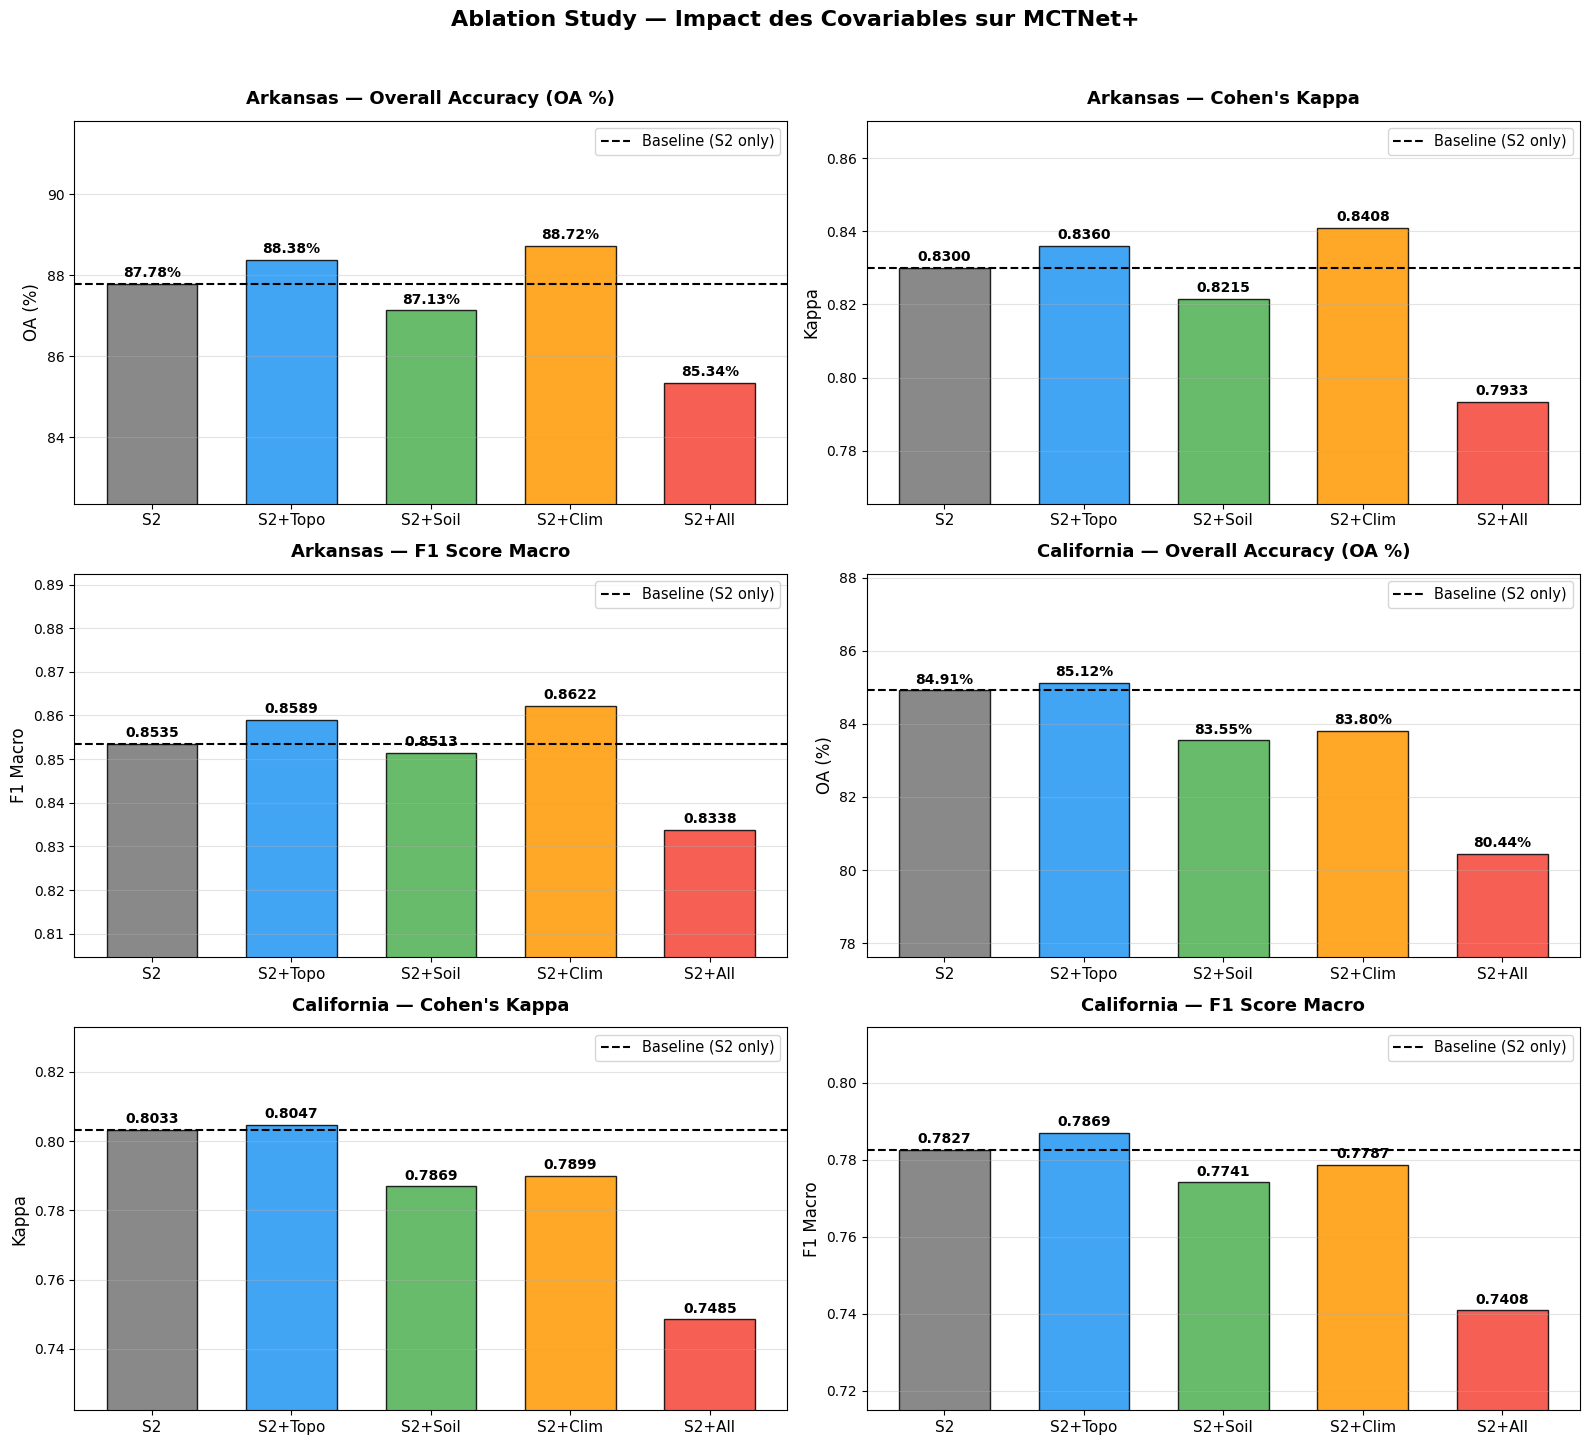

✅ Ablation Study complète sauvegardée : p3_ablation_study.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# 8.3 ABLATION STUDY — OA, Kappa, F1 (style Partie 2)
# ════════════════════════════════════════════════════════════════
configs_short = ['S2', 'S2+Topo', 'S2+Soil', 'S2+Clim', 'S2+All']
colors = ['#757575', '#2196F3', '#4CAF50', '#FF9800', '#F44336']

oas_ar     = [resultats_p3[cfg]['AR']['OA']    * 100 for cfg in configs_short]
oas_cal    = [resultats_p3[cfg]['CAL']['OA']   * 100 for cfg in configs_short]
kappas_ar  = [resultats_p3[cfg]['AR']['Kappa']        for cfg in configs_short]
kappas_cal = [resultats_p3[cfg]['CAL']['Kappa']        for cfg in configs_short]
f1s_ar     = [resultats_p3[cfg]['AR']['F1']           for cfg in configs_short]
f1s_cal    = [resultats_p3[cfg]['CAL']['F1']           for cfg in configs_short]

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Ablation Study — Impact des Covariables sur MCTNet+',
             fontsize=16, fontweight='bold', y=0.98)

def plot_bar(ax, vals, title, ylabel, baseline_val, color_list, is_percent=False):
    bars = ax.bar(configs_short, vals, color=color_list,
                  alpha=0.85, edgecolor='black', width=0.65)
    ax.axhline(y=baseline_val, color='black', linestyle='--',
               linewidth=1.5, label='Baseline (S2 only)')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel(ylabel, fontsize=12)
    y_min = min(vals) * 0.965
    y_max = max(vals) * 1.035
    ax.set_ylim([y_min, y_max])
    for bar, val in zip(bars, vals):
        text = f'{val:.2f}%' if is_percent else f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (y_max - y_min) * 0.01,
                text, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.legend(fontsize=10.5)
    ax.grid(axis='y', alpha=0.35)
    ax.tick_params(axis='x', labelsize=11, rotation=0)

# Arkansas
plot_bar(axes[0][0], oas_ar,    "Arkansas — Overall Accuracy (OA %)",  'OA (%)',   oas_ar[0],    colors, True)
plot_bar(axes[0][1], kappas_ar, "Arkansas — Cohen's Kappa",            'Kappa',    kappas_ar[0], colors)
plot_bar(axes[1][0], f1s_ar,    "Arkansas — F1 Score Macro",           'F1 Macro', f1s_ar[0],    colors)

# California
plot_bar(axes[1][1], oas_cal,    "California — Overall Accuracy (OA %)", 'OA (%)',   oas_cal[0],    colors, True)
plot_bar(axes[2][0], kappas_cal, "California — Cohen's Kappa",           'Kappa',    kappas_cal[0], colors)
plot_bar(axes[2][1], f1s_cal,    "California — F1 Score Macro",          'F1 Macro', f1s_cal[0],    colors)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig(os.path.join(dossier, 'p3_ablation_study.png'), dpi=220, bbox_inches='tight')
plt.show()
print('✅ Ablation Study complète sauvegardée : p3_ablation_study.png')

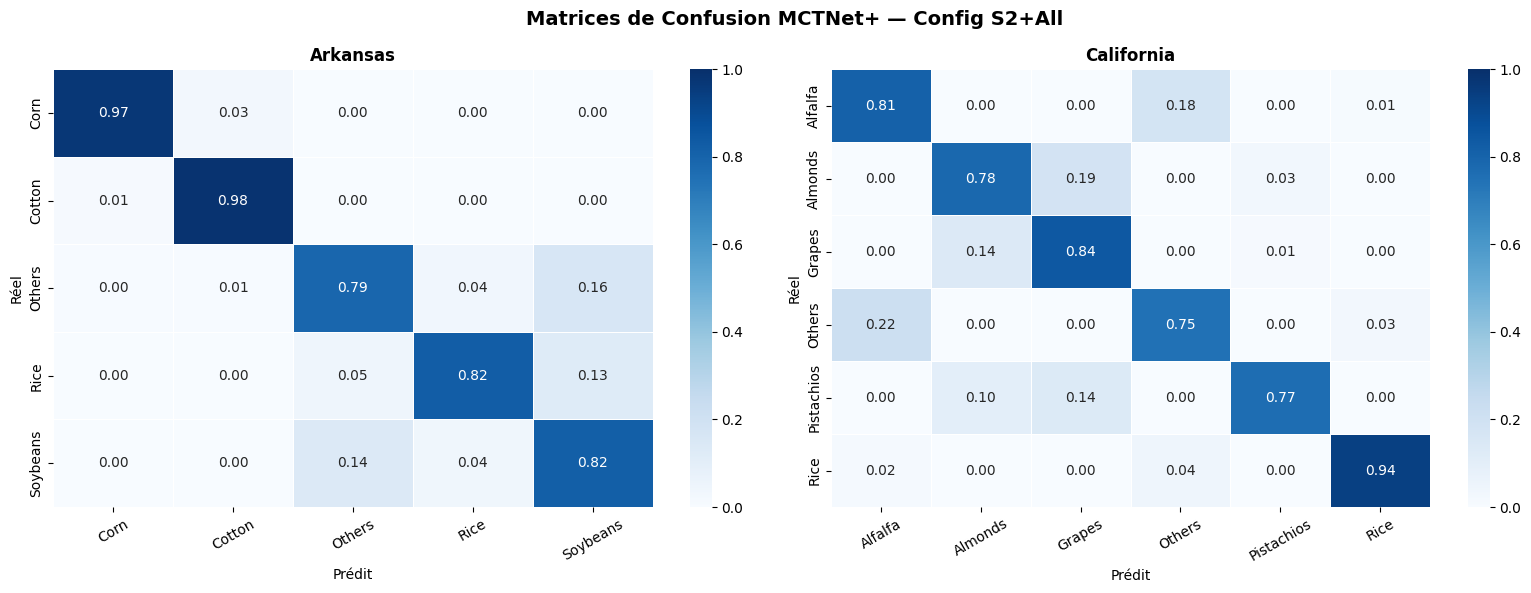

✅ Matrices de confusion sauvegardées


In [ ]:
# ════════════════════════════════════════════════════════════════
# 8.4 Matrices de confusion — config S2+All
# ════════════════════════════════════════════════════════════════
cfg = 'S2+All'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Matrices de Confusion MCTNet+ — Config {cfg}',
             fontsize=14, fontweight='bold')

for ax, zone, titre in zip(axes, ['AR','CAL'], ['Arkansas','California']):
    info = predictions_p3[cfg][zone]
    cm   = confusion_matrix(info['trues'], info['preds'])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=info['le'].classes_,
                yticklabels=info['le'].classes_,
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(dossier+'/p3_confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Matrices de confusion sauvegardées')

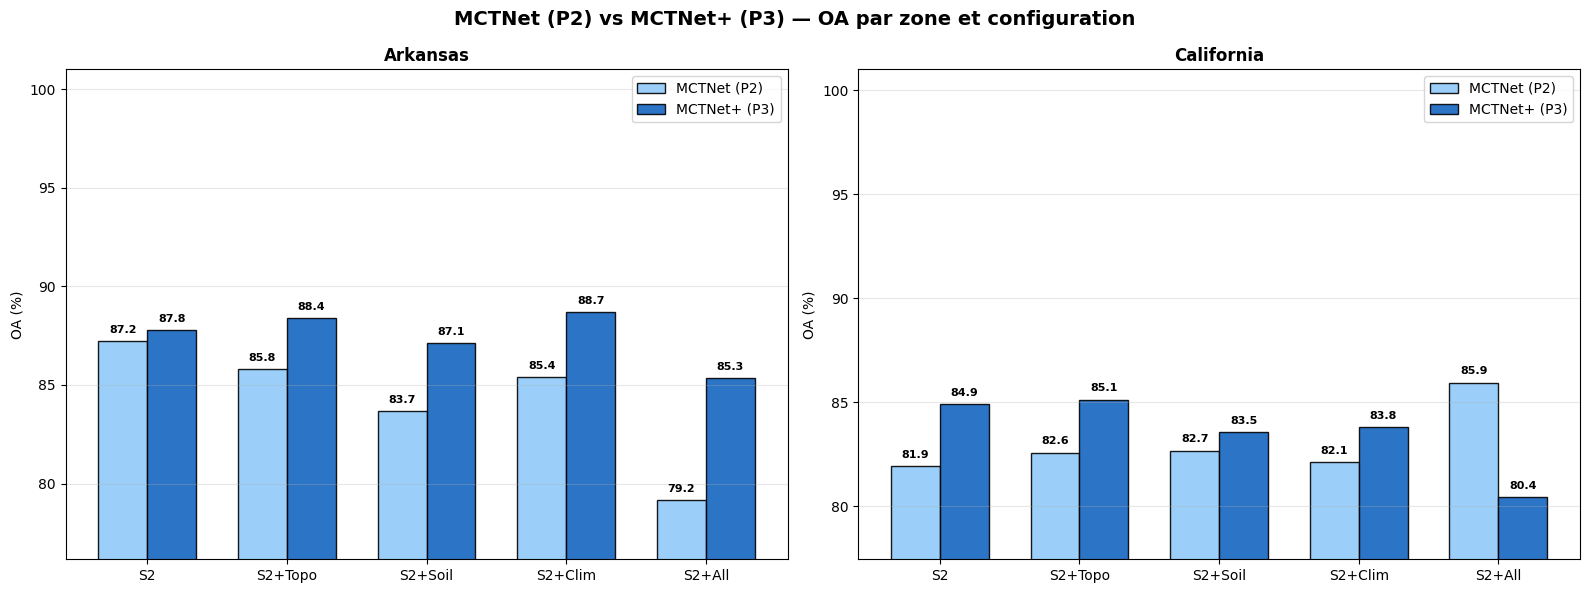

✅ Comparaison P2 vs P3 sauvegardée


In [ ]:
# ════════════════════════════════════════════════════════════════
# 8.5 Comparaison groupée MCTNet vs MCTNet+ — toutes configs
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MCTNet (P2) vs MCTNet+ (P3) — OA par zone et configuration',
             fontsize=14, fontweight='bold')

x     = np.arange(len(configs_short))
width = 0.35

for ax, zone, titre in zip(axes, ['AR','CAL'], ['Arkansas','California']):
    v2 = [resultats_p2[c][zone]['OA']*100 for c in configs_short]
    v3 = [resultats_p3[c][zone]['OA']*100 for c in configs_short]

    b1 = ax.bar(x-width/2, v2, width, label='MCTNet (P2)',
                color='#90CAF9', edgecolor='black', alpha=0.9)
    b2 = ax.bar(x+width/2, v3, width, label='MCTNet+ (P3)',
                color='#1565C0', edgecolor='black', alpha=0.9)

    for bar, val in [(b, v) for b,v in zip(list(b1)+list(b2), v2+v3)]:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_ylabel('OA (%)'); ax.set_xticks(x)
    ax.set_xticklabels(configs_short, fontsize=10)
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([max(0, min(v2+v3)-3), 101])

plt.tight_layout()
plt.savefig(dossier+'/p3_comparaison_p2_p3.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Comparaison P2 vs P3 sauvegardée')

## 9. Résumé final

In [ ]:
print('\n' + '='*72)
print('  RÉSUMÉ FINAL — MCTNet+ (Partie 3)')
print('='*72)
print('  Architecture : ResBlock1D+CBAM_canal → BiGRU+CBAM_temporel → MLP')
print('  Anti-overfitting :')
print(f'    • MixUp (α={MIXUP_ALPHA}) + Bruit gaussien (σ={NOISE_STD})')
print(f'    • Dropout={DROPOUT} + Weight Decay={WEIGHT_DECAY} (AdamW décorrélé BN/bias)')
print(f'    • Label Smoothing={LABEL_SMOOTH}')
print(f'    • CosineAnnealingWarmRestarts (T0=50)')
print(f'    • Batch size={BATCH_SIZE} | proj_dim={PROJ_DIM} | gru_hidden={GRU_HIDDEN}')
print()
print(f'  {"Config":<10} {"Zone":<12} {"OA":>8} {"Kappa":>8} {"F1":>8}')
print('  ' + '-'*50)
for cfg in configs:
    for zone, z_nom in [('AR','Arkansas'), ('CAL','California')]:
        r = resultats_p3[cfg][zone]
        print(f'  {cfg:<10} {z_nom:<12} {r["OA"]:>8.4f} {r["Kappa"]:>8.4f} {r["F1"]:>8.4f}')
print('='*72)


  RÉSUMÉ FINAL — MCTNet+ (Partie 3)
  Architecture : ResBlock1D+CBAM_canal → BiGRU+CBAM_temporel → MLP
  Anti-overfitting :
    • MixUp (α=0.0) + Bruit gaussien (σ=0.02)
    • Dropout=0.4 + Weight Decay=0.0005 (AdamW décorrélé BN/bias)
    • Label Smoothing=0.1
    • CosineAnnealingWarmRestarts (T0=50)
    • Batch size=32 | proj_dim=64 | gru_hidden=128

  Config     Zone               OA    Kappa       F1
  --------------------------------------------------
  S2         Arkansas       0.8778   0.8300   0.8535
  S2         California     0.8491   0.8033   0.7827
  S2+Topo    Arkansas       0.8838   0.8360   0.8589
  S2+Topo    California     0.8512   0.8047   0.7869
  S2+Soil    Arkansas       0.8713   0.8215   0.8513
  S2+Soil    California     0.8355   0.7869   0.7741
  S2+Clim    Arkansas       0.8872   0.8408   0.8622
  S2+Clim    California     0.8380   0.7899   0.7787
  S2+All     Arkansas       0.8534   0.7933   0.8338
  S2+All     California     0.8044   0.7485   0.7408
